# Startup Success Predictor

### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform 
- Exploratory data analysis
- Data Pre-Processing 
- Model Training 
- Choose best model 

### 1) Problem statement
- This project analyzes how various factors such as funding rounds, founder experience, team size, market size, product traction, burn rate, and investor type influence the outcome of a startup, and uses machine learning to predict its success.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/dhrubangtalukdar/startup-funding-and-outcome-dataset
- The data consists of 11 column and 100000 rows.

### 2.1- Importing Data and Required Packages
#### Importing Pandas, Numpy, Matplotlib, Seaborn and warning Library.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

### Importing CSV

In [2]:
df=pd.read_csv('data\startup_success_dataset.csv')

### Show Top 5 Records

In [3]:
df.head()

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,4,13,58,48.225483,594843,18.519211,1.483962e+06,tier2_vc,Health,academic,IPO
1,1,6,221,31.532647,393020,14.298149,8.620568e+05,tier2_vc,Fintech,first_time,Failure
2,3,5,247,4.969722,27636,20.447567,9.726169e+04,none,SaaS,first_time,Failure
3,3,14,229,3.084209,235376,8.177417,1.145785e+06,none,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13.818188,391765,4.879792,8.608949e+05,none,Health,first_time,Acquisition


### Shape of the dataset

In [4]:
df.shape

(100000, 11)

### 3). Analysing Data

In [5]:
df['investor_type'].unique()

array(['tier2_vc', 'none', 'angel', 'tier1_vc'], dtype=object)

In [6]:
df['sector'].unique()

array(['Health', 'Fintech', 'SaaS', 'Ecommerce', 'Climate', 'Crypto',
       'AI'], dtype=object)

In [7]:
df['founder_background'].unique()

array(['academic', 'first_time', 'ex_bigtech', 'serial_founder'],
      dtype=object)

In [8]:
df['outcome'].unique()

array(['IPO', 'Failure', 'Acquisition'], dtype=object)

### 3.1- Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check statistics of data set

In [9]:
# Checking Missing values
df.isnull().sum()

funding_rounds              0
founder_experience_years    0
team_size                   0
market_size_billion         0
product_traction_users      0
burn_rate_million           0
revenue_million             0
investor_type               0
sector                      0
founder_background          0
outcome                     0
dtype: int64

In [11]:
# Checking for Duplicate values
df.duplicated().sum()

np.int64(0)

In [13]:
# Checking for data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   funding_rounds            100000 non-null  int64  
 1   founder_experience_years  100000 non-null  int64  
 2   team_size                 100000 non-null  int64  
 3   market_size_billion       100000 non-null  float64
 4   product_traction_users    100000 non-null  int64  
 5   burn_rate_million         100000 non-null  float64
 6   revenue_million           100000 non-null  float64
 7   investor_type             100000 non-null  object 
 8   sector                    100000 non-null  object 
 9   founder_background        100000 non-null  object 
 10  outcome                   100000 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 8.4+ MB


In [17]:
# Changing data types of column- "revenue_million","burn_rate_million" and "market_size_billion" from float to int
df['burn_rate_million']=df['burn_rate_million'].astype(int) 
df['revenue_million']=df['revenue_million'].astype(int)
df['market_size_billion']=df['market_size_billion'].astype(int)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   funding_rounds            100000 non-null  int64 
 1   founder_experience_years  100000 non-null  int64 
 2   team_size                 100000 non-null  int64 
 3   market_size_billion       100000 non-null  int64 
 4   product_traction_users    100000 non-null  int64 
 5   burn_rate_million         100000 non-null  int64 
 6   revenue_million           100000 non-null  int64 
 7   investor_type             100000 non-null  object
 8   sector                    100000 non-null  object
 9   founder_background        100000 non-null  object
 10  outcome                   100000 non-null  object
dtypes: int64(7), object(4)
memory usage: 8.4+ MB


In [19]:
df.head()

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,4,13,58,48,594843,18,1483962,tier2_vc,Health,academic,IPO
1,1,6,221,31,393020,14,862056,tier2_vc,Fintech,first_time,Failure
2,3,5,247,4,27636,20,97261,none,SaaS,first_time,Failure
3,3,14,229,3,235376,8,1145785,none,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13,391765,4,860894,none,Health,first_time,Acquisition


In [20]:
# Checking statistics of data
df.describe()

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,2.002300,12.024300,150.732000,32.704260,285422.832730,16.275130,7.828186e+05
std,1.414671,7.208089,86.272631,43.035284,159323.885405,15.713896,6.085069e+05
min,0.000000,0.000000,2.000000,0.000000,668.000000,0.000000,1.344000e+03
25%,1.000000,6.000000,76.000000,10.000000,161194.750000,7.000000,3.154852e+05
50%,2.000000,12.000000,151.000000,20.000000,264989.500000,12.000000,6.213620e+05
75%,3.000000,18.000000,226.000000,39.000000,389214.000000,20.000000,1.098920e+06
max,8.000000,24.000000,299.000000,1072.000000,915203.000000,357.000000,4.168442e+06


### 4). Numerical and Categorical Features

In [21]:
cat_features=[feature for feature in df.columns if df[feature].dtype == 'O' ]
numerical_features=[feature for feature in df.columns if df[feature].dtype != 'O']

In [22]:
print('Numeric Features',numerical_features)
print(" ")
print('Categorical Feature',cat_features)

Numeric Features ['funding_rounds', 'founder_experience_years', 'team_size', 'market_size_billion', 'product_traction_users', 'burn_rate_million', 'revenue_million']
 
Categorical Feature ['investor_type', 'sector', 'founder_background', 'outcome']


In [26]:
df.columns

Index(['funding_rounds', 'founder_experience_years', 'team_size',
       'market_size_billion', 'product_traction_users', 'burn_rate_million',
       'revenue_million', 'investor_type', 'sector', 'founder_background',
       'outcome'],
      dtype='object')

### 5). Exploring Data (Visualization)

#### 5.1 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

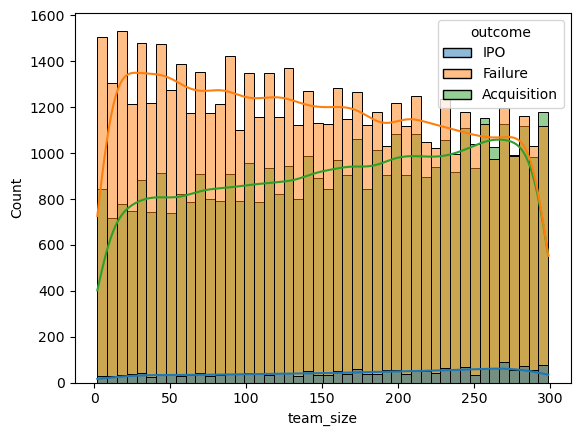

In [29]:
sns.histplot(data=df,x='team_size',kde=True,hue='outcome')
plt.show()

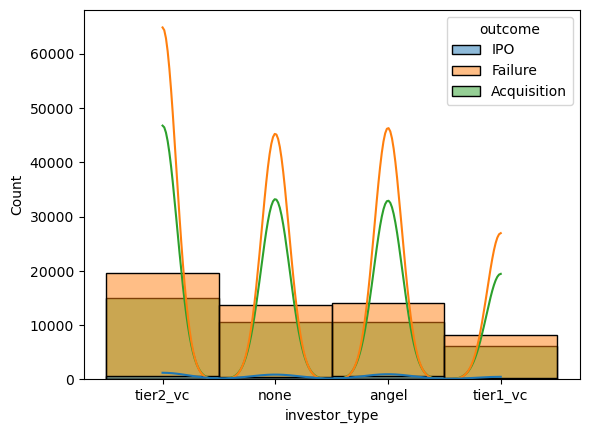

In [30]:
sns.histplot(data=df,x='investor_type',kde=True,hue='outcome')
plt.show()

<Axes: xlabel='sector', ylabel='Count'>

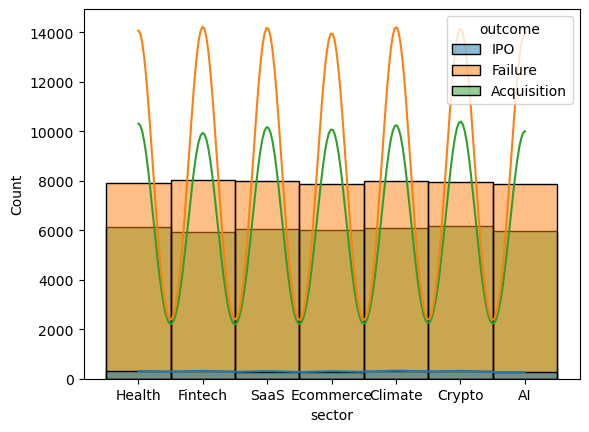

In [31]:
sns.histplot(data=df,x='sector',kde=True,hue='outcome')


<Axes: xlabel='founder_experience_years', ylabel='Count'>

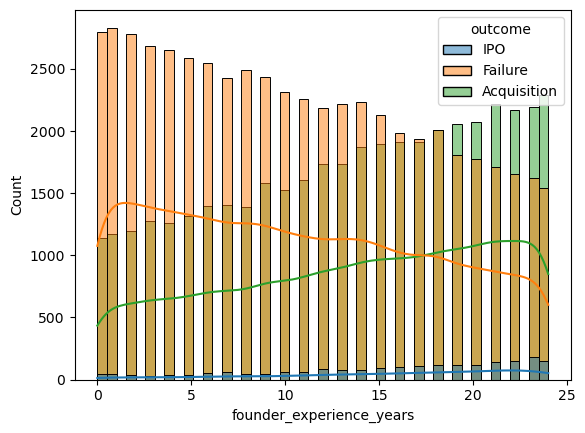

In [32]:
sns.histplot(data=df,x='founder_experience_years',kde=True,hue='outcome')
